In [ ]:
#imports
from google.colab import files
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import os, json

username = ''   # Kaggle username
key    = ''   # API token

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({'username': username, 'key': key}, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

print('Kaggle configured!')

Kaggle configured!


In [ ]:
file_names = os.listdir('data/')
print(f"Files in our data folder: {file_names}")

csv_file_path = f"data/{file_names[1]}"
df = pd.read_csv(csv_file_path)

print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Dataset Information ---")
df.info()

Files in our data folder: ['vg_data_dictionary.csv', 'vgchartz-2024.csv']

--- First 5 Rows ---


,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14



--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


In [ ]:
# Normalize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print('Columns after normalizing names:')
print(df.columns.tolist())
# Drop columns we don't need
cols_to_drop = ['img', 'title', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'last_update']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
# Drop rows missing critical columns
df = df.dropna(subset=['total_sales', 'critic_score', 'developer'])
# Extract year from release_date then drop the original column
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year
df = df.drop(columns=['release_date']).dropna(subset=['year'])

print(f'Rows after cleaning: {len(df)}')
df.info()
print(df.columns.tolist())

Columns after normalizing names:
['img', 'title', 'console', 'genre', 'publisher', 'developer', 'critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'release_date', 'last_update']
Rows after cleaning: 4123
<class 'pandas.core.frame.DataFrame'>
Index: 4123 entries, 0 to 18919
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   console       4123 non-null   object 
 1   genre         4123 non-null   object 
 2   publisher     4123 non-null   object 
 3   developer     4123 non-null   object 
 4   critic_score  4123 non-null   float64
 5   total_sales   4123 non-null   float64
 6   year          4123 non-null   float64
dtypes: float64(3), object(4)
memory usage: 257.7+ KB
['console', 'genre', 'publisher', 'developer', 'critic_score', 'total_sales', 'year']


In [ ]:
# Target encode publisher and developer (replace with mean total_sales)
for col in ['publisher', 'developer']:
    means = df.groupby(col)['total_sales'].transform('mean')
    df[col] = means

# One-hot encode console and genre only
X = df.drop(columns=['total_sales'])
y = df['total_sales']

X_encoded = pd.get_dummies(X, columns=['console', 'genre'], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f'Training samples: {len(X_train)}')
print(f'Test samples:     {len(X_test)}')
print(f'Feature count:    {X_train.shape[1]}')

Training samples: 3232
Test samples:     808
Feature count:    50


In [ ]:
scaler = StandardScaler()
num_cols = ['year', 'critic_score', 'publisher', 'developer']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print('Scaling complete.')

Scaling complete.


Training the Linear Regression model on the dataset...

--- Linear Regression Performance ---
Root Mean Squared Error (RMSE): 0.69 million copies
R-squared (R²): 0.3997


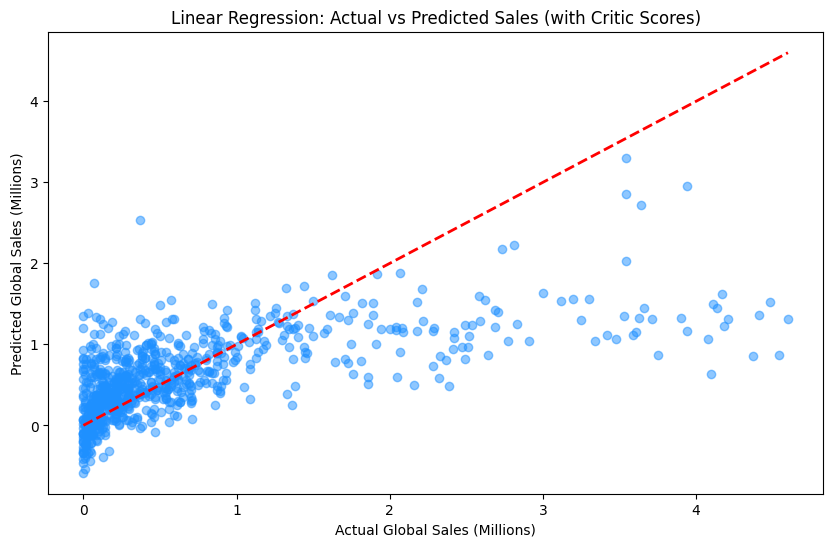

In [ ]:
lr_model = LinearRegression()
print("Training the Linear Regression model on the dataset...")
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("\n--- Linear Regression Performance ---")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.2f} million copies")
print(f"R-squared (R²): {r2_lr:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5, color='dodgerblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Global Sales (Millions)")
plt.ylabel("Predicted Global Sales (Millions)")
plt.title("Linear Regression: Actual vs Predicted Sales (with Critic Scores)")
plt.show()

In [ ]:
y_pred = lr_model.predict(X_test)

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)

print('=' * 45)
print('    LINEAR REGRESSION — TEST SET RESULTS')
print('=' * 45)
print(f'  MSE  (Mean Squared Error):   {mse:.4f} million copies')
print(f'  MAE  (Mean Absolute Error):  {mae:.4f} million copies')
print(f'  RMSE (Root Mean Sq. Error):  {rmse:.4f}')
print(f'  R²   (R-squared Score):      {r2:.4f}')
print('=' * 45)

    LINEAR REGRESSION — TEST SET RESULTS
  MSE  (Mean Squared Error):   0.4775 million copies
  MAE  (Mean Absolute Error):  0.4204 million copies
  RMSE (Root Mean Sq. Error):  0.6910
  R²   (R-squared Score):      0.3997


In [ ]:
# Calculate the average of the actual sales in the test set
avg_sales = y_test.mean()

# Calculate Relative MAE (Error as a percentage of the average)
relative_mae = (mae / avg_sales) * 100

print('=' * 45)
print('    CONTEXTUALIZING PERFORMANCE')
print('=' * 45)
print(f'  Average Sales (Test Set):  {avg_sales:.4f} million')
print(f'  MAE as % of Average:       {relative_mae:.2f}%')
print('=' * 45)

    CONTEXTUALIZING PERFORMANCE
  Average Sales (Test Set):  0.6596 million
  MAE as % of Average:       63.74%
